In [1]:
import pandas as pd
from pathlib import Path

# Load metadata
df = pd.read_csv('data/HAM10000_metadata.csv')

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nClass distribution:\n", df['dx'].value_counts())
print("\nUnique lesions:", df['lesion_id'].nunique())

Dataset shape: (10015, 7)
Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Class distribution:
 dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Unique lesions: 7470


In [2]:
# Define the two image folders
part1_dir = Path('data/HAM10000_images_part_1')
part2_dir = Path('data/HAM10000_images_part_2')

# Create a dictionary: image_id -> full path
image_paths = {}
for folder in [part1_dir, part2_dir]:
    for img_path in folder.glob('*.jpg'):
        image_id = img_path.stem
        image_paths[image_id] = str(img_path)

# Add a new column with the full path
df['image_path'] = df['image_id'].map(image_paths)

# Check that all images were found
print("Images found:", df['image_path'].notna().sum())
print("Missing images:", df['image_path'].isna().sum())

# Show first few rows with the new path column
print("\nFirst 3 rows with image paths:")
print(df[['image_id', 'dx', 'image_path']].head(3))

Images found: 10015
Missing images: 0

First 3 rows with image paths:
       image_id   dx                                    image_path
0  ISIC_0027419  bkl  data\HAM10000_images_part_1\ISIC_0027419.jpg
1  ISIC_0025030  bkl  data\HAM10000_images_part_1\ISIC_0025030.jpg
2  ISIC_0026769  bkl  data\HAM10000_images_part_1\ISIC_0026769.jpg


In [3]:
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold

# test set (15%) + training pool (85%)
# by lesion_id so same lesion is never in both
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, test_idx = next(gss.split(X=df.index.values, 
                                     y=df['dx'].values, 
                                     groups=df['lesion_id'].values))

df_train = df.iloc[train_idx].copy().reset_index(drop=True)
df_test  = df.iloc[test_idx].copy().reset_index(drop=True)

print("Total images:", len(df))
print("Training pool size:", len(df_train))
print("Final held-out test set size:", len(df_test))
print("Unique lesions in test set:", df_test['lesion_id'].nunique())

# 5-fold CV
n_splits = 5
kf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)

df_train['fold'] = -1
for fold_idx, (tr_idx, val_idx) in enumerate(kf.split(df_train.index.values, 
                                                       df_train['dx'].values, 
                                                       df_train['lesion_id'].values)):
    df_train.loc[val_idx, 'fold'] = fold_idx

print("\nFold distribution in training pool:")
print(df_train['fold'].value_counts().sort_index())

print("\nClass distribution in fold 0 (training pool):")
print(df_train[df_train['fold'] == 0]['dx'].value_counts())

Total images: 10015
Training pool size: 8488
Final held-out test set size: 1527
Unique lesions in test set: 1121

Fold distribution in training pool:
fold
0    1714
1    1684
2    1687
3    1672
4    1731
Name: count, dtype: int64

Class distribution in fold 0 (training pool):
dx
nv       1127
bkl       217
mel       175
bcc        85
akiec      52
vasc       31
df         27
Name: count, dtype: int64


In [4]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

# Custom Dataset
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.copy()
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(row['dx_idx'], dtype=torch.long)
        return image, label

# Map string labels to integers (0-6)
class_to_idx = {label: idx for idx, label in enumerate(sorted(df_train['dx'].unique()))}
df_train['dx_idx'] = df_train['dx'].map(class_to_idx)
df_test['dx_idx']  = df_test['dx'].map(class_to_idx)

print("Class to index mapping:", class_to_idx)

# Calculate class weights ONLY on the training pool
class_counts = df_train['dx'].value_counts().sort_index()
class_weights = 1.0 / class_counts.values
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float)

print("\nClass weights:\n", class_weights)

# Image transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Example: use fold 0 for validation
train_dataset = HAM10000Dataset(df_train[df_train['fold'] != 0], transform=train_transform)
val_dataset   = HAM10000Dataset(df_train[df_train['fold'] == 0], transform=val_transform)
test_dataset  = HAM10000Dataset(df_test, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print("\nTrain samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Final test samples:", len(test_dataset))

Class to index mapping: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}

Class weights:
 tensor([0.9460, 0.5891, 0.2847, 2.5135, 0.2847, 0.0464, 2.3356])

Train samples: 6774
Validation samples: 1714
Final test samples: 1527


In [5]:
import torch.nn as nn
import torchvision.models as models

# Loading pre-trained EfficientNet-B0
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Replace the final classifier layer with 7 classes
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 7)

# Move model to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print("Model loaded successfully. Using device:", device)
print("Number of output classes:", 7)

# Loss function with class weights to handles imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Optimizer (fine-tuning with lower learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("\nReady for training")

Model loaded successfully. Using device: cuda
Number of output classes: 7

Ready for training


In [8]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from tqdm import tqdm

def train_one_fold(fold):
    print(f"\n=== Training Fold {fold} ===")
    
    train_df = df_train[df_train['fold'] != fold]
    val_df   = df_train[df_train['fold'] == fold]
    
    train_dataset = HAM10000Dataset(train_df, transform=train_transform)
    val_dataset   = HAM10000Dataset(val_df,   transform=val_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
    
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    num_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_features, 7)
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    
    best_val_bal_acc = 0.0
    patience = 4
    patience_counter = 0
    
    for epoch in range(12):
        model.train()
        for images, labels in tqdm(train_loader, desc=f"Fold {fold} - Epoch {epoch+1}/12"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                preds = outputs.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        acc = accuracy_score(all_labels, all_preds)
        bal_acc = balanced_accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro')
        
        print(f"Epoch {epoch+1} - Val Acc: {acc:.4f} | Balanced Acc: {bal_acc:.4f} | Macro F1: {f1:.4f}")
        
        if bal_acc > best_val_bal_acc:
            best_val_bal_acc = bal_acc
            patience_counter = 0
            torch.save(model.state_dict(), f"best_model_fold_{fold}.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break
    
    print(f"Fold {fold} finished. Best balanced accuracy: {best_val_bal_acc:.4f}\n")

# Run training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
for fold in range(5):
    train_one_fold(fold)


=== Training Fold 0 ===


Fold 0 - Epoch 1/12: 100%|██████████| 106/106 [01:14<00:00,  1.42it/s]


Epoch 1 - Val Acc: 0.5823 | Balanced Acc: 0.6060 | Macro F1: 0.4467


Fold 0 - Epoch 2/12: 100%|██████████| 106/106 [01:10<00:00,  1.50it/s]


Epoch 2 - Val Acc: 0.6505 | Balanced Acc: 0.6700 | Macro F1: 0.5563


...

Epoch 10 - Val Acc: 0.7770 | Balanced Acc: 0.7142 | Macro F1: 0.6488


Fold 4 - Epoch 11/12: 100%|██████████| 106/106 [01:15<00:00,  1.41it/s]


Epoch 11 - Val Acc: 0.7891 | Balanced Acc: 0.7043 | Macro F1: 0.6662


Fold 4 - Epoch 12/12: 100%|██████████| 106/106 [01:14<00:00,  1.43it/s]


Epoch 12 - Val Acc: 0.7932 | Balanced Acc: 0.7267 | Macro F1: 0.6791
Fold 4 finished. Best balanced accuracy: 0.7267



Best model loaded successfully.


Evaluating test set: 100%|██████████| 48/48 [00:15<00:00,  3.04it/s]



=== FINAL RESULTS ON HELD-OUT TEST SET ===
Accuracy:          0.7236
Balanced Accuracy: 0.7028
Macro F1-score:    0.5990
Macro Precision:   0.5471
Macro Recall:      0.7028


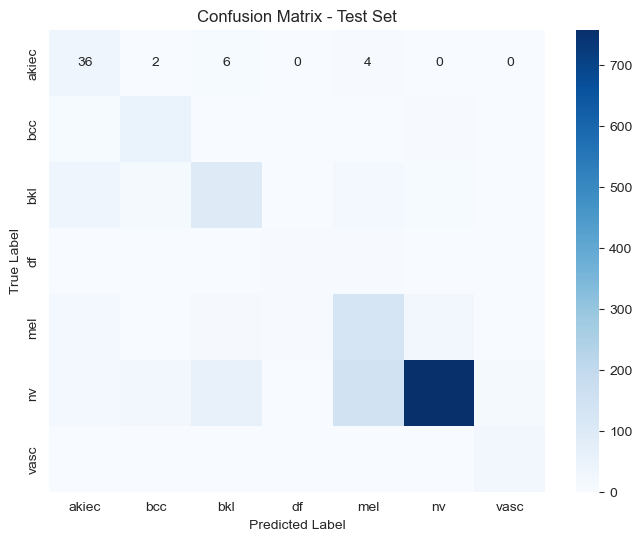

In [6]:
import torchvision.models as models
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

# Load the best saved model
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 7)
model.load_state_dict(torch.load('best_model_fold_2.pth', map_location=device))
model = model.to(device)
model.eval()

print("Best model loaded successfully.")

# Recreate test loader with safer settings
test_dataset = HAM10000Dataset(df_test, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

# Inference with progress bar
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating test set"):
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Metrics
acc = accuracy_score(all_labels, all_preds)
bal_acc = balanced_accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='macro')
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')

print("\n=== FINAL RESULTS ON HELD-OUT TEST SET ===")
print(f"Accuracy:          {acc:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"Macro F1-score:    {f1:.4f}")
print(f"Macro Precision:   {precision:.4f}")
print(f"Macro Recall:      {recall:.4f}")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = sorted(df['dx'].unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Test Set')
plt.show()

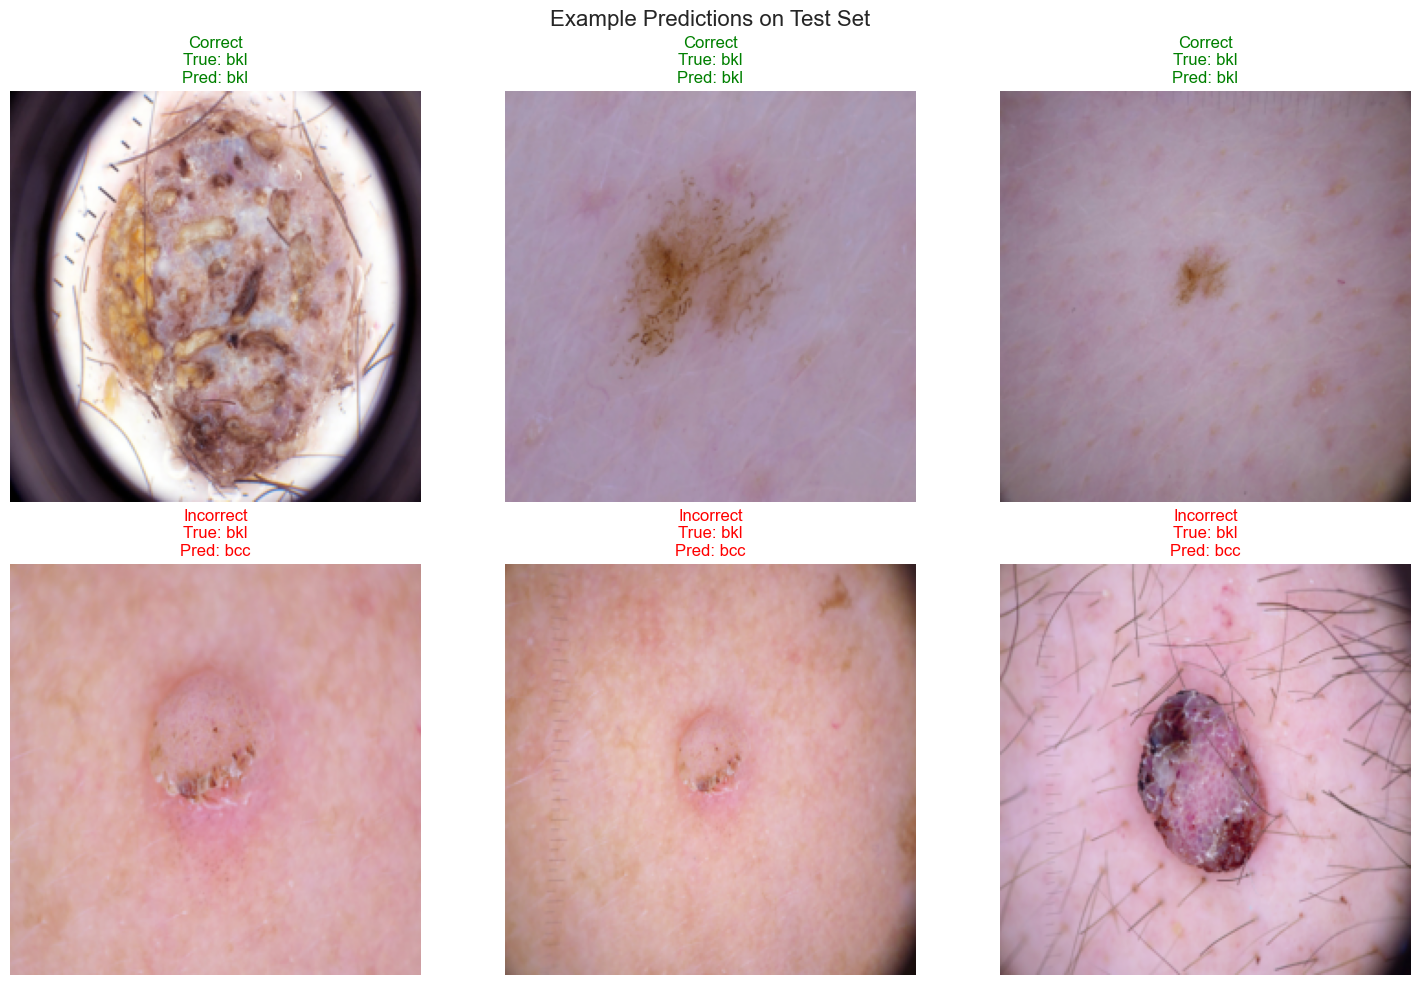

In [7]:
import matplotlib.pyplot as plt

# Re-use the same model and test_loader from Cell 7
model.eval()

# Collect some examples
correct_examples = []
incorrect_examples = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        
        for i in range(len(labels)):
            true_label = class_names[labels[i].item()]
            pred_label = class_names[preds[i].item()]
            
            if len(correct_examples) < 3 and true_label == pred_label:
                correct_examples.append((images[i].cpu(), true_label, pred_label))
            elif len(incorrect_examples) < 3 and true_label != pred_label:
                incorrect_examples.append((images[i].cpu(), true_label, pred_label))
            
            if len(correct_examples) >= 3 and len(incorrect_examples) >= 3:
                break
        if len(correct_examples) >= 3 and len(incorrect_examples) >= 3:
            break

# Plot them
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Example Predictions on Test Set", fontsize=16)

# Correct examples
for i, (img, true, pred) in enumerate(correct_examples):
    img = img.permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Correct\nTrue: {true}\nPred: {pred}", color="green")
    axes[0, i].axis("off")

# Incorrect examples
for i, (img, true, pred) in enumerate(incorrect_examples):
    img = img.permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Incorrect\nTrue: {true}\nPred: {pred}", color="red")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd

# Tabular Confusion Matrix
cm_df = pd.DataFrame(cm, 
                     index=[f"True {cls}" for cls in class_names],
                     columns=[f"Pred {cls}" for cls in class_names])

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("=== TABULAR CONFUSION MATRIX ===\n")
print(cm_df.to_string())

# Display Performance Metrics
metrics_data = {
    "Metric": ["Accuracy", "Balanced Accuracy", "Macro F1-score", 
               "Macro Precision", "Macro Recall"],
    "Value": [0.7236, 0.7028, 0.5990, 0.5471, 0.7028]
}

metrics_df = pd.DataFrame(metrics_data)
print("\n\n=== PERFORMANCE METRICS ===\n")
print(metrics_df.to_string(index=False))

# Save
cm_df.to_csv("confusion_matrix.csv")
metrics_df.to_csv("performance_metrics.csv")
print("\nBoth tables saved as CSV files")

=== TABULAR CONFUSION MATRIX ===

            Pred akiec  Pred bcc  Pred bkl  Pred df  Pred mel  Pred nv  Pred vasc
True akiec          36         2         6        0         4        0          0
True bcc             8        52         1        2         0        3          0
True bkl            34        14        97        1        20        6          0
True df              2         0         0        5         3        0          0
True mel            15         2        11        4       132       21          1
True nv             16        25        58        1       146      758         12
True vasc            0         2         0        1         1        0         25


=== PERFORMANCE METRICS ===

           Metric  Value
         Accuracy 0.7236
Balanced Accuracy 0.7028
   Macro F1-score 0.5990
  Macro Precision 0.5471
     Macro Recall 0.7028

Both tables saved as CSV files (easy to copy into Word/LaTeX)
